Dylan Ross

Select out subsets of the omics data based on targeted pairwise comparisons

## Setup

### Imports

In [55]:
import os
from typing import List
import pickle

import polars as pl
import numpy as np
from scipy import stats
from plotly import graph_objects as pgo
from matplotlib import pyplot as plt, patches, rcParams

### Constants

In [ ]:
# Jupyter server should be running from src/python
CACHE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_cache"
)

FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_figures"
)

# cached metadata table 
META_CACHE = os.path.join(CACHE_DIR, "meta.arrow")
OMICS_CACHE = os.path.join(CACHE_DIR, "combined.arrow")


# key: block label
# value: color
COLORS = {
    "Transcriptomics": "#EF476F",
    "Phosphoproteomics": "#F7866B",
    "Proteomics": "#FFD166",
    "Acetylomics": "#06D6A0",
    "Lipidomics": "#11A2B2",
    "Metabolomics": "#0B6584",
    "Filtered": "#444444"
}

### Load metadata and omics data from cache

In [3]:
meta = pl.read_ipc(META_CACHE)
meta

Sample,Age,Sex,Race,Study,FLT3_ITD,NPM1
str,f64,str,str,str,bool,bool
"""11-00261""",74.0,"""Male""","""White""","""BeatAML""",true,false
"""11-00503""",54.0,"""Female""","""White""","""BeatAML""",true,true
"""11-00475""",65.0,"""Male""","""White""","""BeatAML""",true,true
"""12-00032""",70.0,"""Male""","""White""","""BeatAML""",true,false
"""11-00376""",49.0,"""Male""","""White""","""BeatAML""",true,true
…,…,…,…,…,…,…
"""16-01109-Bridge""",33.0,"""Male""","""Black""","""pilotStudy""",false,false
"""16-01191-Bridge""",65.0,"""Female""","""White""","""pilotStudy""",false,false
"""17-00025-Bridge""",39.0,"""Female""","""White""","""pilotStudy""",true,true


In [4]:
combined = pl.read_ipc(OMICS_CACHE)
combined

Block,Feature,11-00261,11-00503,11-00475,12-00032,11-00376,11-00378,11-00382,11-00388,11-00416,11-00465,11-00466,12-00123,12-00127,12-00145,12-00196,12-00294,12-00383,13-00033,13-00034,13-00075,13-00077,13-00123,13-00149,13-00157,13-00160,13-00186,13-00195,13-00226,13-00262,13-00331,13-00450,13-00468,14-00495,13-00558,13-00581,…,C-95-068,C-01-1665,C-09-1033,C-99-2136,C-05-1782,94-C-376,PS88-0050,C-01-2163,C-02-0350,C-04-0434,C-01-0171,PS88-0140,C-11-2295,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-01-0930,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-99-1700,C-02-1356,C-99-2065,14-00528-Bridge,16-00120-Bridge,16-00494-Bridge,16-00627-Bridge,16-00731-Bridge,16-01100-Bridge,16-01109-Bridge,16-01191-Bridge,17-00025-Bridge,17-00741-Bridge,17-00881-Bridge
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Acetylomics""","""A2M-K1176k""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,0.330127,-1.505467,-0.428963,null,-2.143029,null,-0.497628,-1.37027,-1.787643,null,-0.510944,null,2.104951,-0.382382,-0.304169,null,1.271643,null,0.313458,2.126205,-1.622013,null,0.880241,null,-2.93503,null,null,null,null,null,null,null,null,null,null,null
"""Acetylomics""","""A2M-K912k""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,0.38503,0.695151,-0.219241,null,0.912355,null,null,0.890893,0.79203,0.001479,-1.447282,null,0.818989,-0.03042,null,null,0.277311,null,0.435211,0.545431,0.38928,null,0.454476,null,-0.020518,null,null,null,null,null,null,null,null,null,null,null
"""Acetylomics""","""ABCE1-K343k""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,-1.260764,-0.196359,0.365935,null,-0.641335,null,-0.119836,0.099939,0.551293,null,-1.03373,null,0.41977,-0.715829,-0.281123,null,-0.325684,null,0.658935,0.268563,-1.661094,null,-1.71928,null,0.094878,0.317464,null,null,null,null,null,null,null,null,null,null,null
"""Acetylomics""","""ABCE1-K431k""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,-1.354356,0.582544,0.370127,-0.031272,-0.086364,0.327699,-0.292101,-1.60355,-0.159053,-0.481542,-0.750778,-0.383407,0.373132,-0.205401,-0.688846,-0.799921,-0.366197,-0.039556,0.701408,-0.181248,-0.911242,-1.698226,1.016596,-0.274447,-0.361193,-0.49722,null,null,null,null,null,null,null,null,null,null,null
"""Acetylomics""","""ABHD10-K69k""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,0.512305,-0.641897,null,-0.788261,null,-1.523059,-0.880812,-0.147372,null,-0.379555,null,0.040963,1.265502,0.47155,null,-1.411947,null,-0.87768,-0.02174,-1.051302,null,0.591655,null,-0.609805,0.167879,-1.579952,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Transcriptomics""","""CEP43__2""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.371185,null,null,0.0,null,null,0.087719,0.249785,0.155027,0.099639,null,0.155454,0.156892,0.038594,0.185828,0.141952,0.126895,0.206017,0.094288,0.241965,…,0.077266,0.146562,0.540351,null,null,0.038757,null,0.069963,0.088275,0.338344,0.088325,null,null,0.350199,0.1

In [5]:
# report on the number of features in each block
combined.group_by("Block").len().sort("len", descending=True)

Block,len
str,u32
"""Transcriptomics""",14372
"""Phosphoproteomics""",8362
"""Proteomics""",8059
"""Acetylomics""",3285
"""Lipidomics""",343
"""Metabolomics""",49


## Summarize coverage of omics data by mutation state and population

In [126]:
def _count_samples_with_block_and_total(
    race,
    mut,
    block,
):
    # filter metadata by race 
    _meta = meta.filter(pl.col("Race") == race)
    # filter metadata by mutations
    match mut:
        case "WT":
            _meta = _meta.filter(
                ~pl.col("NPM1")
                & ~pl.col("FLT3_ITD")
            )
        case "NPM1":
            _meta = _meta.filter(
                pl.col("NPM1")
                & ~pl.col("FLT3_ITD")
            )
        case "FLT3-ITD": 
            _meta = _meta.filter(
                ~pl.col("NPM1")
                & pl.col("FLT3_ITD")
            )
        case "NPM1xFLT3-ITD":
            _meta = _meta.filter(
                pl.col("NPM1")
                & pl.col("FLT3_ITD")
            )
    samples = _meta["Sample"].to_list()
    # count the number of samples that have the specified block
    # criterion for "having the block" is not all values are null
    # in that column
    _combined = (
        combined
        .filter(pl.col("Block") == block)
        .select(samples)
    )
    all_rows = len(_combined)
    has_block = len(
        _combined
        .null_count()
        .select(
            pl.all().eq(all_rows)
        )
        .transpose()
        .filter(~pl.col("column_0"))
    )
    return has_block, len(samples)


# key: (race label, mutation label, block)
# value: (sample count with block, sample count with or without block)
omics_counts = {
    (race == "Black", mut, block): _count_samples_with_block_and_total(race, mut, block)
    for race in ["White", "Black"]
    for mut in ["WT", "NPM1", "FLT3-ITD", "NPM1xFLT3-ITD"]
    for block in ["Transcriptomics", "Proteomics", "Phosphoproteomics", "Acetylomics", "Lipidomics", "Metabolomics"]
}

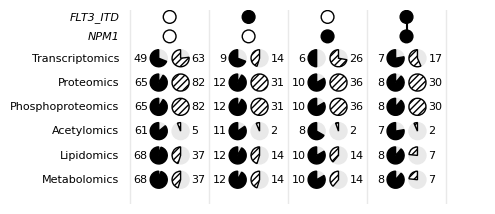

In [147]:
# --- setup ---

# figure and subpanels
fig, ax = plt.subplots(
    figsize=(5, 2.5),
)

# max font size 
rcParams["font.size"] = 8

# colors
c_white = "w"
c_black = "k"
c_border = c_black
c_grey = "#E9E9E9"

# misc parameters
w = 0.35            # bar width
lw = 1.             # line width for borders
r = 0.35           # circle radius
hatch = "/////"      # hatching for white bars
xfactor = 3.25
xoff = 0.45


# --- helper: make a pie ---

def _add_pie(x, y, has_block, total, black=True):
    theta_0 = 90
    proportion = has_block / total
    ax.add_patch(patches.Wedge(
        center=(x, y),
        r=r,
        theta1=theta_0,
        theta2=360 * proportion + theta_0,
        facecolor=c_black if black else c_white,
        edgecolor=c_border,
        hatch=None if black else hatch
    ))
    ax.text(
        x - xoff if black else x + xoff,
        y,
        str(has_block),
        ha="right" if black else "left",
        va="center" 
    )


# --- plot the data ---


# draw dividing lines
for x in np.arange(0, 5 * xfactor, xfactor):
    ax.axvline(
        x + xfactor / 2,
        lw=lw,
        c=c_grey
    )

# plot the field of empty circles
for x in np.arange(xfactor, 5 * xfactor, xfactor):
    for y in range(1, 7):
        for _x in [x - xoff, x + xoff]:
            ax.add_patch(patches.Circle(
                xy=(
                    _x, 
                    y
                ),
                radius=r,
                edgecolor=c_grey,
                lw=lw,
                facecolor=c_grey
            ))

# add block labels
block_to_y = {
    "Transcriptomics": 6,
    "Proteomics": 5,
    "Phosphoproteomics": 4,
    "Acetylomics": 3,
    "Lipidomics": 2,
    "Metabolomics": 1,
}
for blk, y in block_to_y.items():
    ax.text(
        xfactor / 2 - xoff,
        y,
        blk,
        ha="right",
        va="center"
    )

# add pies
mut_to_x = {
    "WT": xfactor,
    "FLT3-ITD": 2 * xfactor,
    "NPM1": 3 * xfactor,
    "NPM1xFLT3-ITD": 4 * xfactor
}
for (black, mut, block), (has_block, total) in omics_counts.items():
    if has_block > 0:
        _add_pie(
            mut_to_x[mut] - xoff if black else mut_to_x[mut] + xoff,
            block_to_y[block],
            has_block,
            total, 
            black=black
        )

# add the mutation indicator circles
ax.add_patch(patches.Circle(
    xy=(
        xfactor, 
        6.9
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_white
))
ax.add_patch(patches.Circle(
    xy=(
        xfactor, 
        7.7
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_white
))
ax.add_patch(patches.Circle(
    xy=(
        xfactor * 2, 
        6.9
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_white
))
ax.add_patch(patches.Circle(
    xy=(
        xfactor * 2, 
        7.7
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_black
))
ax.add_patch(patches.Circle(
    xy=(
        xfactor * 3, 
        6.9
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_black
))
ax.add_patch(patches.Circle(
    xy=(
        xfactor * 3, 
        7.7
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_white
))
ax.plot(
    [xfactor * 4, xfactor * 4], 
    [6.9, 7.7], 
    "k-", 
    lw=1.5,
    zorder=-1
)
ax.add_patch(patches.Circle(
    xy=(
        xfactor * 4, 
        6.9
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_black
))
ax.add_patch(patches.Circle(
    xy=(
        xfactor * 4, 
        7.7
    ),
    radius=r * 0.75,
    edgecolor=c_border,
    lw=lw,
    facecolor=c_black
))
ax.text(
    xfactor / 2 - xoff,
    7.7,
    "FLT3_ITD",
    ha="right",
    va="center",
    fontstyle="italic"
)
ax.text(
    xfactor / 2 - xoff,
    6.9,
    "NPM1",
    ha="right",
    va="center",
    fontstyle="italic"
)

# --- customization ---

ax.set_xlim((0, 5 * xfactor))
ax.set_ylim((0, 8))
ax.set_aspect("equal")
ax.set_axis_off()


# --- finish ---
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURE_DIR, "mutations_omics_coverage_sample_counts.png"),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()

## Create Subsets

### Utility function for selecting subsets and applying transformations/normalizations
- filter columns to only include the selected samples for the subset (with two sample groups)
- filter rows to remove those that do not have at least 5 non-null values in WT and mutant groups
- apply row-wise z-score normalization across subset samples that are not null
    - require at least 5 samples within WT and mutant groups to z-score normalize

In [154]:
def select_subset(
    combined: pl.DataFrame,
    wt_cols: List[str],
    mut_cols: List[str]
) -> pl.DataFrame :
    """
    Select a subset of the combined -omics data DataFrame that contains a specified
    set of samples belonging to WT/mutant groups. 
    Filters rows with fewer than 5 
    Applies a row-wise z-score normalization to the full table 
    using non-null values from WT and mutant sample groups (no imputation).
    Returns the processed DataFrame with the selected subset.
    """
    return (
        combined
        .select(
            "Block",
            "Feature",
            *wt_cols,
            *mut_cols
        )
        .filter(
            (pl.sum_horizontal(~pl.col(wt_cols).is_null()) >= 5)
            & (pl.sum_horizontal(~pl.col(mut_cols).is_null()) >= 5)
        )
        .select(
            "Block",
            "Feature",
            (
                # pack the raw values into a list column
                pl.concat_list(
                    pl.col(wt_cols + mut_cols)
                )
                # compute row-wise z-scores
                .map_elements(
                    lambda x: stats.zscore(x, nan_policy="omit"), 
                    return_dtype=pl.List(pl.Float64)
                )
                # convert list to struct 
                .list.to_struct(
                    fields=wt_cols + mut_cols
                )
                .alias("packed")
            )
        )
        # unpack struct with z-scores back to sample columns
        .unnest("packed")
        # z-score makes NaNs out of null values, change them back
        .fill_nan(None)
    )

### Utility function to plot feature counts from the -omics data blocks before/after subsetting

In [155]:
def plot_filtered_feature_counts(
    combined: pl.DataFrame, 
    subset: pl.DataFrame, 
    figname=None
) :

    def _hex_to_rgba(hex: str, alpha: float) -> str : 
        """ add some transparency to rgb hex code and format it how plotly likes it """
        # assume the hex string starts with #
        ir = int(hex[1:3], 16)
        ig = int(hex[3:5], 16)
        ib = int(hex[5:7], 16)
        return f"rgba({ir}, {ig}, {ib}, {alpha})"

    # feature counts 
    counts = (
        combined
        .group_by("Block").len()
        .rename({"len": "pre"})
        .join(
            (
                subset
                .group_by("Block").len()
                .rename({"len": "post"})
            ), 
            how="left", 
            on="Block"
        )
        .fill_null(0)
        .sort("pre", descending=True)
    )

    # node: 
    #   key: {
    #       "index": index, 
    #       "color": color, 
    #       "label": label
    #       "count": count 
    #       "filtered": label <- for source nodes only
    # }
    node_data = {}

    # construct the node data from feature counts pre- and post-subsetting
    i = 0
    filtered = 0
    for block, pre, post in counts.iter_rows() :
        # add the node for pre-subsetting feature count
        node_data[f"{block}_0"] = {
            "index": i,
            "color": COLORS[block],
            "label": f"{block} ({pre})",
            "count": pre,
            "filtered": pre - post
        }
        filtered += pre - post
        i += 1
        # add the node for post-subsetting feature count
        node_data[f"{block}_1"] = {
            "index": i,
            "color": COLORS[block],
            "label": f"({post}) {block}",
            "count": post
        }
        i += 1

    # add a catch-all node for features that were filtered out
    node_data["Filtered"] = {
        "index": i,
        "color": COLORS["Filtered"],
        "label": f"({filtered}) Filtered",
        "count": filtered
    }

    # construct the link data from the node data
    link_data = {"source": [], "target": [], "value": [], "color": []}
    for block, pre, post in counts.iter_rows():
        # if features for a given block remained after subsetting, add a link
        if post > 0:
            link_data["source"].append(node_data[f"{block}_0"]["index"])
            link_data["target"].append(node_data[f"{block}_1"]["index"])
            link_data["value"].append(node_data[f"{block}_1"]["count"])
            link_data["color"].append(_hex_to_rgba(node_data[f"{block}_0"]["color"], 0.25))
        # always add the link from the block to filtered node
        link_data["source"].append(node_data[f"{block}_0"]["index"])
        link_data["target"].append(node_data["Filtered"]["index"])
        link_data["value"].append(node_data[f"{block}_0"]["filtered"])
        link_data["color"].append(_hex_to_rgba(node_data["Filtered"]["color"], 0.25))

        fig = pgo.Figure(
        data=[
            pgo.Sankey(
                arrangement="freeform",
                node=dict(
                    pad=15,
                    thickness=20,
                    line=dict(color="black", width=0.75),
                    label=[v["label"] for v in sorted(node_data.values(), key=lambda x: x["index"])],
                    color=[v["color"] for v in sorted(node_data.values(), key=lambda x: x["index"])],
                ),
                link=link_data
            )
        ]
    )
    if figname is not None:
        fig.write_image(figname, width=600, height=350, scale=4)
    fig.show()

### NPM1 vs. WT
#### Black patients

In [156]:
# select the sample columns
# WT
wt_cols = meta.filter(
    (pl.col("Race") == "Black")
    & ~pl.col("NPM1")
    & ~pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{wt_cols=}")
# NPM1
mut_cols = meta.filter(
    (pl.col("Race") == "Black")
    & pl.col("NPM1")
    & ~pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{mut_cols=}")

# save the sample columns
with open(os.path.join(CACHE_DIR, "B_NPM1-WT_cols.pkl"), "wb") as pf:
    pickle.dump((wt_cols, mut_cols), pf)

# subset the omics data
subset = select_subset(combined, wt_cols, mut_cols)

# save the subset to file
subset.write_ipc(os.path.join(CACHE_DIR, "B_NPM1-WT.arrow"))

# display
display(subset)

# report on the number of features in each block
subset.group_by("Block").len().sort("len", descending=True)

# plot feature counts before/after subsetting
plot_filtered_feature_counts(
    combined,
    subset,
    figname=os.path.join(FIGURE_DIR, "block-feature-counts_B_NPM1-WT.png")
)

wt_cols=['14-00240', '16-00538', '16-01109', '17-01060', 'C-05-0664', 'C-04-1820', 'C-07-3682', 'C-10-1211', 'C-10-3429', 'C-08-2091', 'C-13-0276', 'C-08-3337', 'C-98-0846', 'C-10-3924', 'C-09-3512', 'C-09-1906', 'C-09-5462', 'C-08-3493', 'C-04-3407', 'C-09-1074', 'C-09-4769', 'C-10-3906', 'C-07-2070', 'C-05-2179', 'C-05-2448', 'C-07-2900', '94-C-279', 'C-05-1287', 'C-04-1098', 'C-09-5381', 'C-09-1608', 'C-02-0218', 'C-96-117', 'C-95-054', 'C-05-0569', 'C-12-4258', 'C-10-0773', 'C-00-0552', 'C-11-5466', 'C-04-1647', 'C-10-0535', 'C-98-0454', 'C-99-0901', 'C-03-2056', 'C-99-0740', 'C-10-0302', 'C-01-1599', 'C-08-2081', 'C-09-0923', '93-C-201', 'C-12-2943', 'C-01-1998', 'C-95-068', 'C-01-1665', 'C-99-2136', 'C-05-1782', 'PS88-0050', 'C-01-2163', 'C-02-0350', 'C-01-0171', 'C-99-1077', 'C-05-0004', 'C-05-3159', 'C-05-4372', 'PS89-0158', 'C-98-0031', '94-C-077', 'C-98-0033', 'C-98-0665', 'C-02-1356', '16-01109-Bridge']
mut_cols=['16-00611', '16-01267', 'C-00-1828', 'C-08-0176', 'C-97-0509',

Block,Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Acetylomics""","""ABCE1-K343k""",null,null,null,null,null,null,null,null,null,null,-0.838282,-0.624118,0.151111,null,null,null,null,-0.188248,0.429697,null,null,-0.036593,null,-0.145677,-0.033645,null,-1.584383,0.012898,-1.098072,0.965523,null,0.250244,-1.322249,-1.695762,-1.635027,…,null,-0.140179,2.361958,1.536411,null,null,-0.999118,0.41329,null,-0.177168,0.514831,0.80646,1.405383,-0.697856,-0.276018,0.300813,null,0.241682,null,1.030216,-1.530333,null,-1.607543,0.799746,null,null,null,null,null,null,1.025175,1.156672,-1.890791,0.076858,null,1.230859,1.548219
"""Acetylomics""","""ABCE1-K431k""",null,null,-1.028028,null,null,null,null,null,null,null,-0.865705,-1.789377,0.220516,-1.318946,-0.117615,-0.033988,-1.526824,-0.045951,-2.578672,0.613604,0.36294,-0.381843,-0.281695,0.43189,0.496521,-0.54481,0.015303,-0.084556,0.466726,-1.300411,-0.700501,0.683246,-0.85248,-0.861615,0.130126,…,-0.153664,-1.991846,-0.909355,0.428235,-0.435701,-0.305293,-0.79962,1.726352,0.925855,0.854008,0.5857,-1.124601,0.759213,-0.012474,0.698768,0.068292,-0.076564,0.489069,0.915052,0.730267,-0.221741,-1.248071,2.292413,0.495595,null,null,null,null,null,-2.275428,-1.105495,0.093409,-1.055544,0.463156,1.394,1.453251,1.881365
"""Acetylomics""","""ABHD10-K69k""",null,null,-0.199762,null,null,null,null,null,null,null,0.910202,null,null,0.854089,0.677453,-0.175468,0.019684,0.882953,null,0.438117,1.045747,null,1.712273,1.211222,null,1.82955,0.260572,1.111893,0.680578,null,0.118538,null,null,-0.418678,0.278047,…,-0.463894,0.419562,-1.274957,null,-0.02663,-1.35982,-0.278104,-1.165523,-1.278057,null,-1.349216,-0.785303,null,null,-0.309438,null,-1.757585,null,-1.346808,-1.480299,null,-0.217094,null,-0.542918,null,null,null,null,null,0.396157,0.012399,null,null,null,-1.843014,0.301,-0.688709
"""Acetylomics""","""ACAA2-K137k""",null,null,-0.234271,null,null,null,null,null,null,null,0.061006,0.75446,0.962263,1.03617,-0.313588,-0.543079,0.263938,-0.403506,1.390664,-0.61002,1.734611,-0.392312,1.284246,0.698487,1.180215,1.332395,-0.408508,0.674791,0.001713,-0.330295,-0.123266,0.753936,-3.783153,0.985298,-0.111182,…,-0.525745,1.527909,-0.740634,-0.053621,-0.307784,-1.516966,0.202169,0.353931,-0.739214,0.288899,-0.081713,-0.489202,-0.736526,-0.625875,-0.868215,-0.897078,-1.842554,0.40247,-1.729719,-0.352657,-0.175356,-0.165638,-1.134669,0.944652,null,null,null,null,null,0.772109,-0.713317,0.740756,-0.603962,-0.622239,0.854501,0.813592,-0.871109
"""Acetylomics""","""ACAA2-K181k""",null,null,null,null,null,null,null,null,null,null,1.51654,0.883171,null,null,null,null,null,-0.69369,null,null,null,0.033532,null,0.854575,null,null,-1.120795,0.575139,-0.252827,-1.675575,null,0.364468,null,0.602561,0.674771,…,null,1.275,-1.169909,-0.383343,null,null,null,0.037631,null,null,-0.708075,-1.524193,-0.420379,0.764043,0.100405,-1.428595,null,null,null,-0.189212,-0.464523,null,0.751129,1.47807,null,null,null,null,null,null,-0.284789,0.662559,-0.202176,null,null,1.313156,-0.

#### White patients 

In [158]:
# select the sample columns
# WT
wt_cols = meta.filter(
    (pl.col("Race") == "White")
    & ~pl.col("NPM1")
    & ~pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{wt_cols=}")
# NPM1
mut_cols = meta.filter(
    (pl.col("Race") == "White")
    & pl.col("NPM1")
    & ~pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{mut_cols=}")

# save the sample columns
with open(os.path.join(CACHE_DIR, "W_NPM1-WT_cols.pkl"), "wb") as pf:
    pickle.dump((wt_cols, mut_cols), pf)

# subset the omics data
subset = select_subset(combined, wt_cols, mut_cols)

# save the subset to file
subset.write_ipc(os.path.join(CACHE_DIR, "W_NPM1-WT.arrow"))

# display
display(subset)

# report on the number of features in each block
subset.group_by("Block").len().sort("len", descending=True)

# plot feature counts before/after subsetting
plot_filtered_feature_counts(
    combined,
    subset,
    figname=os.path.join(FIGURE_DIR, "block-feature-counts_W_NPM1-WT.png")
)

wt_cols=['13-00033', '13-00034', '13-00077', '13-00149', '13-00160', '13-00186', '13-00226', '13-00468', '13-00558', '13-00602', '14-00127', '14-00193', '14-00528', '14-00423', '14-00434', '14-00514', '14-00608', '14-00613', '14-00711', '14-00712', '15-00043', '15-00888', '15-00137', '15-00287', '15-00377', '15-00563', '15-00578', '15-00742', '15-00777', '15-00813', '15-00837', '15-00870', '15-00976', '16-00001', '16-00094', '16-00306', '16-00351', '16-00354', '16-00479', '16-00481', '16-00494', '16-00519', '16-00627', '16-00751', '16-00882', '16-00818', '18-00149', '16-01004', '16-01102', '16-01191', '16-01201', '16-01220', '16-01270', '17-00072', '17-00322', '17-00325', '17-00328', '18-00251', '17-00500', '17-00678', '17-00676', '17-00763', '17-00878', '17-00881', '17-00896', '17-00901', '18-00103', '18-00105', '18-00190', '18-00203', '18-00218', '18-00290', '18-00408', '18-00414', '19-00084', '14-00126', '17-00649', '14-00528-Bridge', '16-00494-Bridge', '16-00627-Bridge', '16-01191-

Block,Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,…,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00302,15-00653,15-00855,16-00035,16-00056,16-00886,16-00504,16-00811,16-00817,16-01061,16-01100,16-01151,16-01227,17-00021,17-00361,17-00444,17-00689,17-00741,17-00770,17-00834,17-01054,18-00101,18-00260,19-00092,16-01100-Bridge,17-00741-Bridge
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Lipidomics""","""neg_LPI 20:4_[M-H]-__A""",-2.558738,0.795162,0.97623,-0.090384,-0.779717,-1.911617,0.481327,1.707531,-0.584952,0.189373,1.500703,1.529258,-0.36337,-0.072131,-1.299666,-0.035141,1.086122,1.291685,0.619827,-0.115282,-0.591146,null,-1.502006,0.624248,0.818995,-0.467447,0.934236,null,null,null,0.519581,null,null,null,null,…,null,0.764121,-0.893906,-1.34287,0.014759,-0.5765,0.063724,-0.610736,0.027682,0.771281,0.919659,0.485558,null,null,null,null,null,null,null,null,null,-0.219745,null,null,null,null,null,null,0.201629,null,null,null,-0.170198,null,null,null,null
"""Lipidomics""","""neg_LPG 22:6_[M-H]-__A""",-0.165502,-2.035608,-0.117098,0.646218,0.35398,-0.022091,-0.100974,-0.288598,1.795841,-1.432571,1.733659,-0.685309,0.046978,0.08257,-0.711224,1.046861,0.420963,-0.419688,0.252011,1.463302,0.26231,null,0.509236,-0.848968,1.074197,0.926556,0.559682,null,null,null,0.633913,null,null,null,null,…,null,-0.751277,0.446357,-0.565308,-2.089273,0.075244,0.201496,0.535684,-2.737078,1.28586,0.307185,-0.237112,null,null,null,null,null,null,null,null,null,-1.083319,null,null,null,null,null,null,0.552795,null,null,null,-0.495384,null,null,null,null
"""Lipidomics""","""neg_LPI 20:3_[M-H]-__A""",-1.8964,0.23673,-1.456134,-2.009352,-0.133513,-0.581791,1.577424,-0.888133,-1.059433,-0.148965,-0.00561,0.476895,-1.41227,-0.029443,-0.373866,1.847104,-0.485397,0.011802,0.259353,0.609152,0.747616,null,-0.22135,-0.203859,-0.472358,-0.817407,-0.079071,null,null,null,1.518262,null,null,null,null,…,null,1.749374,1.803024,-1.879035,0.03084,-0.905855,-0.443178,-1.107387,-0.675935,1.282868,1.136048,0.382012,null,null,null,null,null,null,null,null,null,-0.379702,null,null,null,null,null,null,1.011988,null,null,null,1.428456,null,null,null,null
"""Lipidomics""","""neg_LPG 22:5_[M-H]-__A""",-0.842299,-2.040217,-0.694473,1.334882,-1.254541,-1.233284,1.265894,0.494197,0.340125,0.156723,0.976255,-0.337024,-0.909148,0.292356,0.258718,0.786376,1.351137,-0.321756,-0.371422,1.195911,1.869961,null,-0.723997,0.697767,-0.915076,2.390522,1.098687,null,null,null,0.164292,null,null,null,null,…,null,-1.185898,-0.024964,-0.209186,-0.419047,-1.006273,-0.894467,-0.381653,-1.265135,1.269757,-0.414544,-0.639994,null,null,null,null,null,null,null,null,null,-0.465573,null,null,null,null,null,null,1.969097,null,null,null,0.074032,null,null,null,null
"""Lipidomics""","""neg_LPI 18:1_[M-H]-__A""",-0.407379,0.282973,0.144362,0.874648,0.62348,0.907535,-1.632562,1.152992,-1.152357,-0.424237,-1.045362,0.990322,-0.929067,-2.730211,-0.487886,-2.213403,0.685869,0.055953,-0.010594,0.034047,-0.32767,null,0.451693,-0.867512,-0.721081,-0.59118,0.074912,null,null,null,-0.951838,null,null,null,null,…,null,0.861852,-1.460416,-1.320613,0.438778,-0.37896,0.164094,0.544508,0.646069,-1.335282,1.70667,0.609797,null,null,null,null,null,null,null,null,null,0.959268,null,null,null,null,null,null,0.45482,null,null,null,-0.074782,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

### FLT3-ITD vs. WT
#### Black patients

In [159]:
# select the sample columns
# WT
wt_cols = meta.filter(
    (pl.col("Race") == "Black")
    & ~pl.col("NPM1")
    & ~pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{wt_cols=}")
# NPM1
mut_cols = meta.filter(
    (pl.col("Race") == "Black")
    & ~pl.col("NPM1")
    & pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{mut_cols=}")

# save the sample columns
with open(os.path.join(CACHE_DIR, "B_FLT3-ITD-WT_cols.pkl"), "wb") as pf:
    pickle.dump((wt_cols, mut_cols), pf)

# subset the omics data
subset = select_subset(combined, wt_cols, mut_cols)

# save the subset to file
subset.write_ipc(os.path.join(CACHE_DIR, "B_FLT3-ITD-WT.arrow"))

# display
display(subset)

# report on the number of features in each block
subset.group_by("Block").len().sort("len", descending=True)

# plot feature counts before/after subsetting
plot_filtered_feature_counts(
    combined,
    subset,
    figname=os.path.join(FIGURE_DIR, "block-feature-counts_B_FLT3-ITD-WT.png")
)

wt_cols=['14-00240', '16-00538', '16-01109', '17-01060', 'C-05-0664', 'C-04-1820', 'C-07-3682', 'C-10-1211', 'C-10-3429', 'C-08-2091', 'C-13-0276', 'C-08-3337', 'C-98-0846', 'C-10-3924', 'C-09-3512', 'C-09-1906', 'C-09-5462', 'C-08-3493', 'C-04-3407', 'C-09-1074', 'C-09-4769', 'C-10-3906', 'C-07-2070', 'C-05-2179', 'C-05-2448', 'C-07-2900', '94-C-279', 'C-05-1287', 'C-04-1098', 'C-09-5381', 'C-09-1608', 'C-02-0218', 'C-96-117', 'C-95-054', 'C-05-0569', 'C-12-4258', 'C-10-0773', 'C-00-0552', 'C-11-5466', 'C-04-1647', 'C-10-0535', 'C-98-0454', 'C-99-0901', 'C-03-2056', 'C-99-0740', 'C-10-0302', 'C-01-1599', 'C-08-2081', 'C-09-0923', '93-C-201', 'C-12-2943', 'C-01-1998', 'C-95-068', 'C-01-1665', 'C-99-2136', 'C-05-1782', 'PS88-0050', 'C-01-2163', 'C-02-0350', 'C-01-0171', 'C-99-1077', 'C-05-0004', 'C-05-3159', 'C-05-4372', 'PS89-0158', 'C-98-0031', '94-C-077', 'C-98-0033', 'C-98-0665', 'C-02-1356', '16-01109-Bridge']
mut_cols=['16-00088', 'C-09-0143', 'C-08-2480', 'C-12-0858', 'C-09-2182'

Block,Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,…,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Acetylomics""","""A2M-K1176k""",null,null,-1.339967,null,null,null,null,null,null,null,-0.182612,0.702337,null,null,1.04497,-0.175184,null,null,null,null,-0.352551,null,0.307193,null,null,1.78673,1.298248,null,-1.671435,1.265748,-0.512503,null,null,null,null,…,null,0.198324,-0.877663,1.169131,null,null,0.449576,-0.299006,null,null,-0.36672,-1.227282,null,2.19983,-0.25307,-0.17594,null,1.378058,0.433138,2.220789,-1.47554,null,null,null,null,null,-0.531903,-0.544306,-0.296456,-0.73023,null,-0.49145,-0.445042,null,null,-1.360607,0.992074
"""Acetylomics""","""A2M-K912k""",null,null,0.009608,null,null,null,null,null,null,null,null,null,0.871803,null,null,null,null,null,null,null,0.613184,-0.525111,-1.48187,null,null,null,1.280274,null,0.568678,0.130107,-1.141774,1.519677,2.406317,null,null,…,null,-1.530285,0.081461,null,null,null,-0.440354,-1.454967,null,null,null,0.409024,-1.084362,0.288292,-1.137923,null,null,-0.621221,-0.356097,-0.171031,-0.433218,null,null,null,null,null,null,null,-1.680568,null,null,-0.194462,1.128927,null,-0.639982,0.08036,-0.323751
"""Acetylomics""","""ABCE1-K343k""",null,null,null,null,null,null,null,null,null,null,-0.881052,-0.645914,0.205238,null,null,null,null,-0.167356,0.511107,null,null,-0.000849,null,-0.120616,0.002388,null,-1.700223,0.05349,-1.166284,1.09941,null,0.31408,-1.412417,-1.822509,-1.755826,…,-0.11458,2.632605,1.726208,null,null,-1.057639,0.493093,null,-0.155191,0.60458,0.92477,1.582348,-0.726873,-0.263722,0.369601,null,0.304679,null,1.170438,-1.640879,null,-1.72565,0.917397,null,null,null,-0.184184,-0.330258,null,-0.128081,0.708239,null,-0.196296,-0.624395,1.285424,1.312299,null
"""Acetylomics""","""ABCE1-K431k""",null,null,-1.193409,null,null,null,null,null,null,null,-1.015451,-2.028094,0.175399,-1.512349,-0.195302,-0.10362,-1.740251,-0.116735,-2.893417,0.606351,0.331542,-0.484981,-0.375187,0.407134,0.47799,-0.663646,-0.049581,-0.159058,0.445325,-1.492029,-0.834334,0.6827,-1.000952,-1.010966,0.076302,…,-2.250066,-1.063305,0.403126,-0.544027,-0.401058,-0.943,1.826282,0.948679,0.869911,0.575758,-1.299284,0.765985,-0.080034,0.699718,0.008513,-0.150297,0.46982,0.936835,0.734251,-0.309458,-1.434647,2.446868,0.476974,null,null,null,-0.863635,-0.11316,0.298127,-0.052057,1.536018,0.763128,0.630433,0.424948,0.230915,1.522579,0.601
"""Acetylomics""","""ABHD10-K69k""",null,null,-0.283902,null,null,null,null,null,null,null,0.862803,null,null,0.804833,0.62235,-0.258804,-0.057193,0.834652,null,0.375091,1.002835,null,1.691424,1.173787,null,1.812583,0.191669,1.07117,0.625579,null,0.044934,null,null,-0.510064,0.209723,…,0.355923,-1.394688,null,-0.10504,-1.48236,-0.364837,-1.281632,-1.397891,null,-1.471405,-0.888826,null,null,-0.397209,null,-1.893292,null,-1.468917,-1.606827,null,-0.301809,null,-0.638418,null,null,null,null,0.204551,0.205136,1.263324,0.368447,0.942401,-0.192661,-0.316421,null,null,-1.256141
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…

#### White patients

In [160]:
# select the sample columns
# WT
wt_cols = meta.filter(
    (pl.col("Race") == "White")
    & ~pl.col("NPM1")
    & ~pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{wt_cols=}")
# NPM1
mut_cols = meta.filter(
    (pl.col("Race") == "White")
    & ~pl.col("NPM1")
    & pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{mut_cols=}")

# save the sample columns
with open(os.path.join(CACHE_DIR, "W_FLT3-ITD-WT_cols.pkl"), "wb") as pf:
    pickle.dump((wt_cols, mut_cols), pf)

# subset the omics data
subset = select_subset(combined, wt_cols, mut_cols)

# save the subset to file
subset.write_ipc(os.path.join(CACHE_DIR, "W_FLT3-ITD-WT.arrow"))

# display
display(subset)

# report on the number of features in each block
subset.group_by("Block").len().sort("len", descending=True)

# plot feature counts before/after subsetting
plot_filtered_feature_counts(
    combined,
    subset,
    figname=os.path.join(FIGURE_DIR, "block-feature-counts_W_FLT3-ITD-WT.png")
)

wt_cols=['13-00033', '13-00034', '13-00077', '13-00149', '13-00160', '13-00186', '13-00226', '13-00468', '13-00558', '13-00602', '14-00127', '14-00193', '14-00528', '14-00423', '14-00434', '14-00514', '14-00608', '14-00613', '14-00711', '14-00712', '15-00043', '15-00888', '15-00137', '15-00287', '15-00377', '15-00563', '15-00578', '15-00742', '15-00777', '15-00813', '15-00837', '15-00870', '15-00976', '16-00001', '16-00094', '16-00306', '16-00351', '16-00354', '16-00479', '16-00481', '16-00494', '16-00519', '16-00627', '16-00751', '16-00882', '16-00818', '18-00149', '16-01004', '16-01102', '16-01191', '16-01201', '16-01220', '16-01270', '17-00072', '17-00322', '17-00325', '17-00328', '18-00251', '17-00500', '17-00678', '17-00676', '17-00763', '17-00878', '17-00881', '17-00896', '17-00901', '18-00103', '18-00105', '18-00190', '18-00203', '18-00218', '18-00290', '18-00408', '18-00414', '19-00084', '14-00126', '17-00649', '14-00528-Bridge', '16-00494-Bridge', '16-00627-Bridge', '16-01191-

Block,Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,…,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,16-00120,16-00498,16-00731,16-01185,17-00028,17-00115,17-00123,17-00634,17-00915,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Lipidomics""","""neg_LPI 20:4_[M-H]-__A""",-2.330839,0.745847,0.91195,-0.066505,-0.698861,-1.737205,0.457952,1.582805,-0.520195,0.190129,1.393072,1.419268,-0.316927,-0.04976,-1.175834,-0.015827,1.012758,1.201331,0.585004,-0.089344,-0.525877,null,-1.36145,0.589061,0.76771,-0.412401,0.873426,null,null,null,0.493044,null,null,null,null,…,null,null,null,null,null,null,null,-0.181026,null,null,null,null,-1.152771,-1.701126,1.43678,-1.005514,-0.083709,1.425026,0.074498,null,0.017265,-1.58834,null,0.547034,null,0.407377,null,null,null,null,null,null,null,0.694047,-0.015469,null,null
"""Lipidomics""","""neg_LPG 22:6_[M-H]-__A""",-0.318568,-2.295431,-0.267401,0.539489,0.230569,-0.16697,-0.250357,-0.448691,1.75474,-1.657969,1.689008,-0.868049,-0.093959,-0.056335,-0.895444,0.963004,0.301376,-0.587265,0.122779,1.403218,0.133666,null,0.394688,-1.041051,0.9919,0.835831,0.448013,null,null,null,0.526483,null,null,null,null,…,null,null,null,null,null,null,null,0.173553,null,null,null,null,-1.453486,-1.114748,-0.285534,1.916713,-0.247392,-0.308821,1.842932,null,-0.637353,-0.212938,null,0.28335,null,1.329301,null,null,null,null,null,null,null,-0.620979,-0.16483,null,null
"""Lipidomics""","""neg_LPI 20:3_[M-H]-__A""",-1.951129,0.191914,-1.508817,-2.064605,-0.18005,-0.630411,1.538838,-0.938176,-1.110272,-0.195574,-0.051552,0.433195,-1.464748,-0.075496,-0.42152,1.809771,-0.533568,-0.034059,0.214642,0.566067,0.705174,null,-0.268295,-0.250722,-0.520469,-0.867122,-0.125355,null,null,null,1.479401,null,null,null,null,…,null,null,null,null,null,null,null,1.109712,null,null,null,null,1.444364,-0.119399,-0.609237,1.549761,0.380917,-0.804395,1.022895,null,-0.949633,-1.217242,null,2.56728,null,0.822015,null,null,null,null,null,null,null,-0.546427,0.497759,null,null
"""Lipidomics""","""neg_LPG 22:5_[M-H]-__A""",-0.875474,-2.021524,-0.734049,1.207438,-1.269866,-1.24953,1.141437,0.403153,0.255752,0.080292,0.864338,-0.392077,-0.939428,0.210052,0.17787,0.682681,1.222988,-0.37747,-0.424986,1.074483,1.719348,null,-0.762295,0.597909,-0.945099,2.217369,0.981469,null,null,null,0.087533,null,null,null,null,…,null,null,null,null,null,null,null,1.019193,null,null,null,null,-2.398549,-1.460197,0.218457,-0.33877,-1.216026,0.293021,1.570876,null,-0.45528,0.532255,null,0.662236,null,-0.09301,null,null,null,null,null,null,null,-0.208639,1.013086,null,null
"""Lipidomics""","""neg_LPI 18:1_[M-H]-__A""",-0.437225,0.245409,0.108347,0.830469,0.582109,0.862988,-1.648711,1.105701,-1.173874,-0.453894,-1.068075,0.94485,-0.95308,-2.734089,-0.516832,-2.223058,0.6438,0.020926,-0.044876,-0.000734,-0.358408,null,0.412243,-0.892214,-0.74742,-0.618971,0.039674,null,null,null,-0.975597,null,null,null,null,…,null,null,null,null,null,null,null,0.835534,null,null,null,null,0.839484,-0.204481,1.069129,0.569307,-0.410855,-1.014818,-0.942319,null,-0.730735,-0.70005,null,1.892084,null,1.306822,null,null,null,null,null,null,null,-0.472817,1.032037,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

### FLT3-ITDxNPM1

#### Black patients

In [161]:
# select the sample columns
# WT
wt_cols = meta.filter(
    (pl.col("Race") == "Black")
    & ~pl.col("NPM1")
    & ~pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{wt_cols=}")
# NPM1
mut_cols = meta.filter(
    (pl.col("Race") == "Black")
    & pl.col("NPM1")
    & pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{mut_cols=}")

# save the sample columns
with open(os.path.join(CACHE_DIR, "B_FLT3-ITDxNPM1-WT_cols.pkl"), "wb") as pf:
    pickle.dump((wt_cols, mut_cols), pf)

# subset the omics data
subset = select_subset(combined, wt_cols, mut_cols)

# save the subset to file
subset.write_ipc(os.path.join(CACHE_DIR, "B_FLT3-ITDxNPM1-WT.arrow"))

# display
display(subset)

# report on the number of features in each block
subset.group_by("Block").len().sort("len", descending=True)

# plot feature counts before/after subsetting
plot_filtered_feature_counts(
    combined,
    subset,
    figname=os.path.join(FIGURE_DIR, "block-feature-counts_B_FLT3-ITDxNPM1-WT.png")
)

wt_cols=['14-00240', '16-00538', '16-01109', '17-01060', 'C-05-0664', 'C-04-1820', 'C-07-3682', 'C-10-1211', 'C-10-3429', 'C-08-2091', 'C-13-0276', 'C-08-3337', 'C-98-0846', 'C-10-3924', 'C-09-3512', 'C-09-1906', 'C-09-5462', 'C-08-3493', 'C-04-3407', 'C-09-1074', 'C-09-4769', 'C-10-3906', 'C-07-2070', 'C-05-2179', 'C-05-2448', 'C-07-2900', '94-C-279', 'C-05-1287', 'C-04-1098', 'C-09-5381', 'C-09-1608', 'C-02-0218', 'C-96-117', 'C-95-054', 'C-05-0569', 'C-12-4258', 'C-10-0773', 'C-00-0552', 'C-11-5466', 'C-04-1647', 'C-10-0535', 'C-98-0454', 'C-99-0901', 'C-03-2056', 'C-99-0740', 'C-10-0302', 'C-01-1599', 'C-08-2081', 'C-09-0923', '93-C-201', 'C-12-2943', 'C-01-1998', 'C-95-068', 'C-01-1665', 'C-99-2136', 'C-05-1782', 'PS88-0050', 'C-01-2163', 'C-02-0350', 'C-01-0171', 'C-99-1077', 'C-05-0004', 'C-05-3159', 'C-05-4372', 'PS89-0158', 'C-98-0031', '94-C-077', 'C-98-0033', 'C-98-0665', 'C-02-1356', '16-01109-Bridge']
mut_cols=['17-00313', 'C-09-0261', 'C-05-0319', 'C-01-2143', 'C-12-1118'

Block,Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,…,C-03-2056,C-99-0740,C-10-0302,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Acetylomics""","""A2M-K1176k""",null,null,-1.021367,null,null,null,null,null,null,null,-0.022805,0.740725,null,null,1.036347,-0.016397,null,null,null,null,-0.169428,null,0.399796,null,null,1.676335,1.254875,null,-1.307356,1.226833,-0.307434,null,null,null,null,…,null,0.449903,null,-0.954165,null,0.305864,-0.622492,1.143473,null,null,0.522644,-0.12323,null,null,-0.181653,-0.924142,null,2.032756,-0.083596,-0.017049,null,1.323734,0.508461,2.050839,-1.138338,null,null,null,null,null,-0.080826,-0.826109,-1.676824,-1.075612,-1.279265,-0.192983,-2.255521
"""Acetylomics""","""A2M-K912k""",null,null,0.177304,null,null,null,null,null,null,null,null,null,0.876356,null,null,null,null,null,null,null,0.666672,-0.256237,-1.031959,null,null,null,1.207537,null,0.630587,0.275002,-0.756216,1.40164,2.120512,null,null,…,0.038245,1.223012,null,0.732346,null,-1.071213,0.235561,null,null,null,-0.187517,-1.010147,null,null,null,0.501143,-0.709667,0.403256,-0.753093,null,null,-0.334161,-0.119203,0.030845,-0.181731,null,null,null,null,null,-1.707076,-0.096186,null,-2.056839,0.366556,-2.681949,-0.739614
"""Acetylomics""","""ABCE1-K431k""",null,null,-1.172932,null,null,null,null,null,null,null,-0.995073,-2.007153,0.195114,-1.491695,-0.17538,-0.083749,-1.71947,-0.096857,-2.871994,0.625826,0.35117,-0.464898,-0.355165,0.42672,0.497537,-0.643464,-0.02974,-0.139157,0.46489,-1.471386,-0.814057,0.702134,-0.980582,-0.990591,0.096072,…,2.087702,0.567593,0.903131,-0.214879,-2.229001,-1.042901,0.422715,-0.523912,-0.381022,-0.922662,1.845079,0.967964,0.88924,0.595251,-1.278749,0.785372,-0.060176,0.719141,0.028321,-0.1304,0.489372,0.956127,0.753655,-0.289473,-1.414036,2.46532,0.496522,null,null,null,0.003308,0.293308,1.289469,1.089381,0.324549,0.46478,0.302145
"""Acetylomics""","""ABHD10-K69k""",null,null,-0.186076,null,null,null,null,null,null,null,0.921293,null,null,0.865312,0.689088,-0.161839,0.032856,0.894108,null,0.450311,1.056521,null,1.721489,1.221609,null,1.838492,0.273181,1.122512,0.692206,null,0.13148,null,null,-0.40448,0.290616,…,null,-1.183788,null,-0.449591,0.4318,-1.258758,null,-0.013349,-1.343423,-0.264235,-1.14958,-1.261851,null,-1.332843,-0.770249,null,null,-0.295496,null,-1.740257,null,-1.330441,-1.46362,null,-0.203368,null,-0.528431,null,null,null,0.172163,null,0.542954,0.381487,-0.948347,-0.625784,-1.869127
"""Acetylomics""","""ACAA2-K137k""",null,null,-0.221031,null,null,null,null,null,null,null,0.079481,0.785227,0.996714,1.071931,-0.301753,-0.535313,0.28601,-0.393265,1.432709,-0.60344,1.782753,-0.381873,1.324404,0.728262,1.21853,1.373407,-0.398356,0.704146,0.019137,-0.318757,-0.108058,0.784694,-3.832822,1.020157,-0.095759,…,0.858013,-0.570752,-0.504943,-0.517672,1.572387,-0.736369,-0.037178,-0.295847,-1.526463,0.223146,0.377598,-0.734925,0.311413,-0.065768,-0.48048,-0.732188,-0.619577,-0.866212,-0.895587,-1.857823,0.426998,-1.742988,-0.341515,-0.161071,-0.15118,-1.137389,0.978791,null,null,null,-0.875664,0.623223,-0.022974,0.015903,-0

#### White patients

In [162]:
# select the sample columns
# WT
wt_cols = meta.filter(
    (pl.col("Race") == "White")
    & ~pl.col("NPM1")
    & ~pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{wt_cols=}")
# NPM1
mut_cols = meta.filter(
    (pl.col("Race") == "White")
    & pl.col("NPM1")
    & pl.col("FLT3_ITD")
)["Sample"].to_list()
print(f"{mut_cols=}")

# save the sample columns
with open(os.path.join(CACHE_DIR, "W_FLT3-ITDxNPM1-WT_cols.pkl"), "wb") as pf:
    pickle.dump((wt_cols, mut_cols), pf)

# subset the omics data
subset = select_subset(combined, wt_cols, mut_cols)

# save the subset to file
subset.write_ipc(os.path.join(CACHE_DIR, "W_FLT3-ITDxNPM1-WT.arrow"))

# display
display(subset)

# report on the number of features in each block
subset.group_by("Block").len().sort("len", descending=True)

# plot feature counts before/after subsetting
plot_filtered_feature_counts(
    combined,
    subset,
    figname=os.path.join(FIGURE_DIR, "block-feature-counts_W_FLT3-ITDxNPM1-WT.png")
)

wt_cols=['13-00033', '13-00034', '13-00077', '13-00149', '13-00160', '13-00186', '13-00226', '13-00468', '13-00558', '13-00602', '14-00127', '14-00193', '14-00528', '14-00423', '14-00434', '14-00514', '14-00608', '14-00613', '14-00711', '14-00712', '15-00043', '15-00888', '15-00137', '15-00287', '15-00377', '15-00563', '15-00578', '15-00742', '15-00777', '15-00813', '15-00837', '15-00870', '15-00976', '16-00001', '16-00094', '16-00306', '16-00351', '16-00354', '16-00479', '16-00481', '16-00494', '16-00519', '16-00627', '16-00751', '16-00882', '16-00818', '18-00149', '16-01004', '16-01102', '16-01191', '16-01201', '16-01220', '16-01270', '17-00072', '17-00322', '17-00325', '17-00328', '18-00251', '17-00500', '17-00678', '17-00676', '17-00763', '17-00878', '17-00881', '17-00896', '17-00901', '18-00103', '18-00105', '18-00190', '18-00203', '18-00218', '18-00290', '18-00408', '18-00414', '19-00084', '14-00126', '17-00649', '14-00528-Bridge', '16-00494-Bridge', '16-00627-Bridge', '16-01191-

Block,Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00870,15-00976,16-00001,16-00094,…,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01191-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00811,15-00872,15-00983,16-00041,16-00109,16-00271,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01098,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,19-00154,17-00025-Bridge
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Lipidomics""","""neg_LPI 20:4_[M-H]-__A""",-2.352878,0.724649,0.890797,-0.087925,-0.720454,-1.759082,0.436675,1.561836,-0.541739,0.168779,1.372051,1.398253,-0.338416,-0.071176,-1.197557,-0.037234,0.991633,1.180257,0.563762,-0.110771,-0.547422,null,-1.383224,0.56782,0.746518,-0.433916,0.852263,null,null,null,0.471777,null,null,null,null,…,-2.151639,null,null,null,null,null,null,1.350474,null,null,null,null,-0.182678,0.940756,-0.989665,0.41568,null,null,null,null,null,null,null,-1.261537,null,null,null,null,null,null,-0.60739,null,null,null,null,null,null
"""Lipidomics""","""neg_LPG 22:6_[M-H]-__A""",-0.206187,-2.14324,-0.15605,0.634592,0.331892,-0.057642,-0.139349,-0.333689,1.82537,-1.518615,1.760962,-0.744602,0.0139,0.050766,-0.771445,1.049578,0.401273,-0.469473,0.226273,1.480927,0.23694,null,0.492706,-0.91412,1.077892,0.924966,0.544958,null,null,null,0.621847,null,null,null,null,…,-0.71264,null,null,null,null,null,null,-2.14456,null,null,null,null,0.868025,-1.398008,-0.057437,-0.069973,null,null,null,null,null,null,null,-0.513877,null,null,null,null,null,null,-0.115222,null,null,null,null,null,null
"""Lipidomics""","""neg_LPI 20:3_[M-H]-__A""",-1.93021,0.22721,-1.484931,-2.044448,-0.147249,-0.600632,1.58317,-0.910462,-1.083712,-0.162878,-0.017889,0.47011,-1.440567,-0.041994,-0.390339,1.855921,-0.50314,-0.00028,0.25009,0.603873,0.743913,null,-0.236087,-0.218396,-0.489952,-0.838931,-0.092188,null,null,null,1.523334,null,null,null,null,…,-1.237204,null,null,null,null,null,null,0.127982,null,null,null,null,0.191793,1.288713,0.329359,2.947448,null,null,null,null,null,null,null,-0.614092,null,null,null,null,null,null,-0.346598,null,null,null,null,null,null
"""Lipidomics""","""neg_LPG 22:5_[M-H]-__A""",-0.784424,-1.929149,-0.643162,1.29608,-1.17836,-1.158047,1.230156,0.492725,0.345494,0.170237,0.953377,-0.301586,-0.848304,0.299847,0.267703,0.77193,1.311613,-0.286995,-0.334456,1.16328,1.807399,null,-0.671375,0.687256,-0.853969,2.304845,1.070373,null,null,null,0.17747,null,null,null,null,…,-0.226115,null,null,null,null,null,null,-2.252275,null,null,null,null,0.229568,-1.133086,0.355775,0.137679,null,null,null,null,null,null,null,-0.887024,null,null,null,null,null,null,-0.642404,null,null,null,null,null,null
"""Lipidomics""","""neg_LPI 18:1_[M-H]-__A""",-0.323721,0.365046,0.226754,0.955364,0.704772,0.988175,-1.546093,1.233069,-1.06699,-0.34054,-0.96024,1.070773,-0.844212,-2.641224,-0.404044,-2.125602,0.767018,0.138547,0.072153,0.116692,-0.244196,null,0.53338,-0.782798,-0.636704,-0.5071,0.157463,null,null,null,-0.866931,null,null,null,null,…,-0.266625,null,null,null,null,null,null,0.249241,null,null,null,null,-1.865925,0.694489,-0.663325,-0.475441,null,null,null,null,null,null,null,0.181378,null,null,null,null,null,null,0.630472,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Transcriptomics""","""CEP43__2""",null,-1